# Exercício Prático: Análise Exploratória de Dados de Hotel Booking
**Dataset:** `hotel_bookings.csv`  
**Objetivo:** Explorar o comportamento de demanda, cancelamentos, preços e perfis de clientes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

---
## 1. Carregamento e Conhecimento Inicial dos Dados

In [2]:
df = pd.read_csv('hotel_bookings.csv')
print(f"Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dimensões: 119390 linhas e 32 colunas.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Respostas da Seção 1:
1. **Quantas instâncias e quantos atributos existem?**  
   O conjunto possui **119.390 instâncias** (linhas) e **32 atributos** (colunas).

2. **Quais atributos são numéricos e quais são categóricos?**  
   - **Numéricos (20):** `lead_time`, `adr`, dias de espera, estadias (`stays_*`), pessoas (`adults`, `children`, `babies`), alterações, cancelamentos prévios, etc.  
   - **Categóricos (12):** `hotel`, `arrival_date_month`, `meal`, `country`, `market_segment`, `distribution_channel`, `reserved_room_type`, `assigned_room_type`, `deposit_type`, `customer_type`, `reservation_status`, `reservation_status_date`.

3. **Quais atributos são binários?**  
   `is_canceled` (0 ou 1) e `is_repeated_guest` (0 ou 1).

4. **Quais atributos representam características da reserva, do cliente, da estadia e do hotel?**  
   - **Hotel:** `hotel`.  
   - **Reserva:** `lead_time`, datas de chegada, `deposit_type`, `agent`, `company`, `reservation_status`, `is_canceled`.  
   - **Cliente:** `adults`, `children`, `babies`, `country`, `is_repeated_guest`, `customer_type`, `required_car_parking_spaces`, `total_of_special_requests`.  
   - **Estadia:** `stays_in_weekend_nights`, `stays_in_week_nights`, `meal`, tipos de quarto, `adr`.

---
## 2. Qualidade dos Dados

In [4]:
# Valores ausentes
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, 'Percentual (%)': missing_pct})
missing_df[missing_df['Faltantes'] > 0].sort_values(by='Faltantes', ascending=False)

,Faltantes,Percentual (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [5]:
# Duplicados
print(f"Total de duplicados: {df.duplicated().sum()} ({df.duplicated().sum() / len(df) * 100:.2f}%)")

Total de duplicados: 31994 (26.80%)


In [6]:
# Quantidade de valores distintos
df.nunique().sort_values(ascending=False)

adr                               8879
reservation_status_date            926
lead_time                          479
company                            352
agent                              333
country                            177
days_in_waiting_list               128
previous_bookings_not_canceled      73
arrival_date_week_number            53
stays_in_week_nights                35
arrival_date_day_of_month           31
booking_changes                     21
stays_in_weekend_nights             17
previous_cancellations              15
adults                              14
arrival_date_month                  12
assigned_room_type                  12
reserved_room_type                  10
market_segment                       8
total_of_special_requests            6
children                             5
meal                                 5
babies                               5
distribution_channel                 5
required_car_parking_spaces          5
customer_type            

### Respostas da Seção 2:
5. **Existem valores faltantes? Em quais atributos e em que quantidade?**  
   Sim: `company` (112.593 / 94,31%), `agent` (16.340 / 13,69%), `country` (488 / 0,41%) e `children` (4 / <0,01%).

6. **Existem registros duplicados?**  
   Sim, existem **31.994 registros duplicados** (~26,79% do total).

7. **Quais atributos possuem grande quantidade de valores distintos?**  
   `adr` (8.994), `reservation_status_date` (926), `lead_time` (479), `company` (352), `agent` (333) e `country` (177).

8. **Quais problemas de qualidade precisam ser considerados antes de uma análise posterior?**  
   Alta ausência em `company` (94%), nulos em `agent` e `country`, reservas sem hóspedes (0 adultos, crianças e bebês) e diárias com valores negativos ou zerados.

---
## 3. Estatística Descritiva

In [7]:
cols_destaque = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'booking_changes', 'days_in_waiting_list', 'adr', 'total_of_special_requests'
]

desc = df[cols_destaque].describe().T
desc['median'] = df[cols_destaque].median()
desc['range'] = desc['max'] - desc['min']
desc['IQR'] = desc['75%'] - desc['25%']

desc[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'range', 'IQR']]

,count,mean,std,min,25%,median,75%,max,range,IQR
lead_time,119390.00,104.01,106.86,0.00,18.00,69.00,160.00,737.00,737.00,142.00
stays_in_weekend_nights,119390.00,0.93,1.00,0.00,0.00,1.00,2.00,19.00,19.00,2.00
stays_in_week_nights,119390.00,2.50,1.91,0.00,1.00,2.00,3.00,50.00,50.00,2.00
adults,119390.00,1.86,0.58,0.00,2.00,2.00,2.00,55.00,55.00,0.00
children,119386.00,0.10,0.40,0.00,0.00,0.00,0.00,10.00,10.00,0.00
babies,119390.00,0.01,0.10,0.00,0.00,0.00,0.00,10.00,10.00,0.00
previous_cancellations,119390.00,0.09,0.84,0.00,0.00,0.00,0.00,26.00,26.00,0.00
booking_changes,119390.00,0.22,0.65,0.00,0.00,0.00,0.00,21.00,21.00,0.00
days_in_waiting_list,119390.00,2.32,17.59,0.00,0.00,0.00,0.00,391.00,391.00,0.00
adr,119390.00,101.83,50.54,-6.38,69.29,94.58,126.00,5400.00,5406.38,56.71


---
## 4. Visualizações e Perguntas de Investigação

### Gráfico 1 – Distribuição do tempo de antecedência das reservas (`lead_time`)

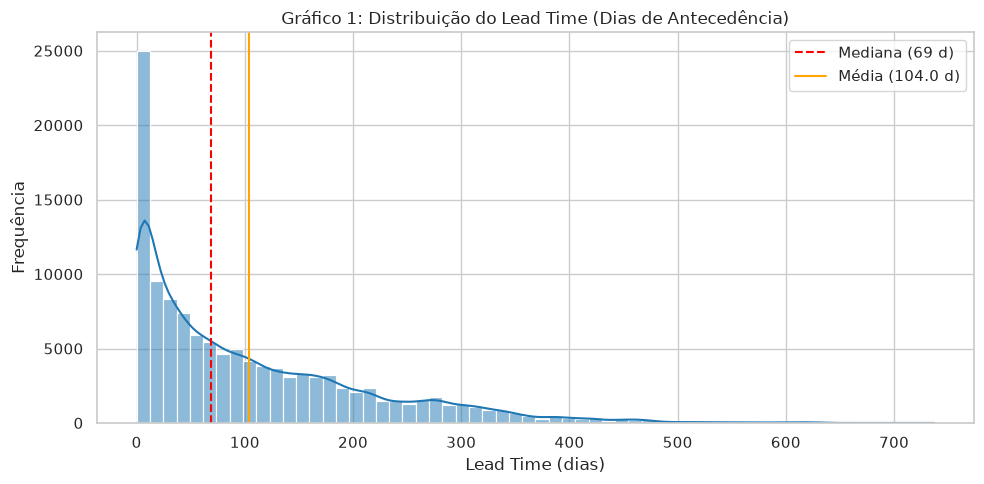

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='lead_time', bins=60, kde=True, color='#1f77b4')
plt.title('Gráfico 1: Distribuição do Lead Time (Dias de Antecedência)')
plt.xlabel('Lead Time (dias)')
plt.ylabel('Frequência')
plt.axvline(df['lead_time'].median(), color='red', linestyle='--', label=f'Mediana ({df["lead_time"].median():.0f} d)')
plt.axvline(df['lead_time'].mean(), color='orange', linestyle='-', label=f'Média ({df["lead_time"].mean():.1f} d)')
plt.legend()
plt.tight_layout()
plt.show()

#### Respostas ao Gráfico 1:
1. **Em que faixa de antecedência está concentrada a maior parte das reservas?**  
   Entre **0 e 30 dias**, com pico no dia 0 (reservas feitas no próprio dia).
2. **A distribuição parece simétrica ou assimétrica?**  
   É **assimétrica à direita (positiva)**, com média (104 dias) superior à mediana (69 dias).
3. **Existe uma cauda longa para valores elevados?**  
   Sim, estende-se até mais de 700 dias.
4. **Há indícios de valores extremos?**  
   Sim, há várias reservas feitas entre 400 e 737 dias de antecedência.
5. **O que o formato sugere sobre o planejamento das reservas?**  
   A maioria dos clientes planeja a curto prazo (menos de 2 meses), enquanto reservas longas são casos específicos.

### Gráfico 2 – Distribuição do preço médio diário (`adr`)

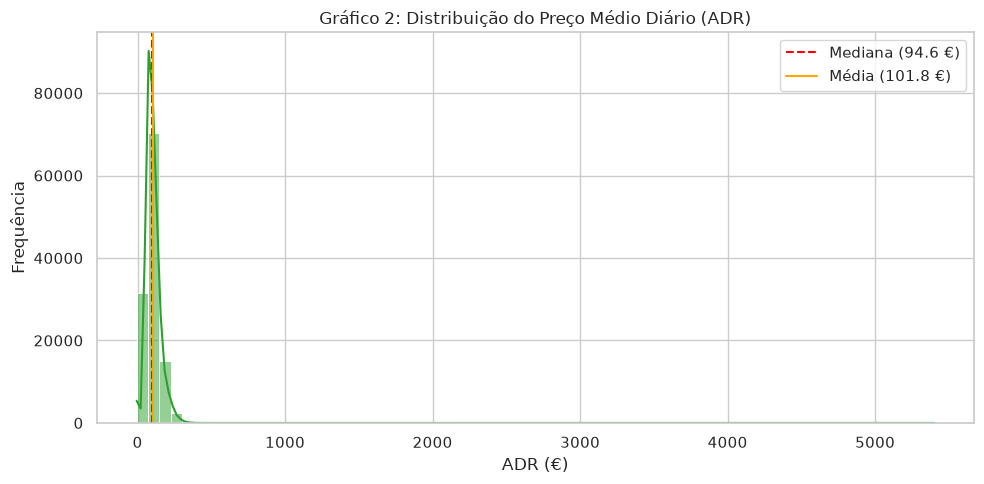

In [67]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='adr', bins=70, kde=True, color='#2ca02c')
plt.title('Gráfico 2: Distribuição do Preço Médio Diário (ADR)')
plt.xlabel('ADR (€)')
plt.ylabel('Frequência')
plt.axvline(df['adr'].median(), color='red', linestyle='--', label=f'Mediana ({df["adr"].median():.1f} €)')
plt.axvline(df['adr'].mean(), color='orange', linestyle='-', label=f'Média ({df["adr"].mean():.1f} €)')
plt.legend()
plt.tight_layout()
plt.show()

#### Respostas ao Gráfico 2:
6. **Em qual faixa de preço está concentrada a maior parte das reservas?**  
   Entre **60 € e 150 €**, com mediana de **94,57 €**.
7. **A distribuição apresenta assimetria?**  
   Sim, assimetria positiva à direita.
8. **Existem valores muito afastados da concentração principal?**  
   Sim, há um valor isolado extremo de **5.400 €** e valores negativos/zerados.
9. **A média parece representar bem o preço típico? Compare com a mediana.**  
   A **mediana (94,57 €) representa melhor** o valor típico, pois a média (101,83 €) é puxada por preços altos.
10. **Que cuidados devem ser tomados ao utilizar ADR em análises posteriores?**  
    Filtrar valores negativos/zerados e tratar o outlier de 5.400 €.

### Gráfico 3 – Boxplot do ADR por tipo de hotel

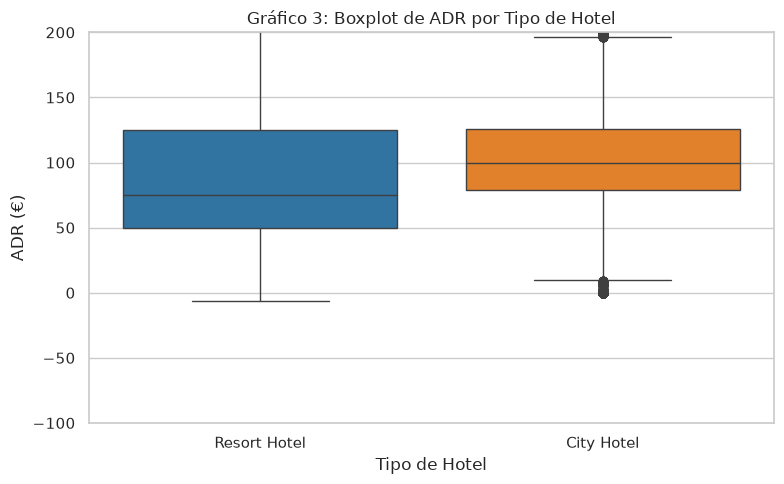

,mean,std,min,50%,max
hotel,,,,,
City Hotel,105.304465,43.602954,0.00,99.9,5400.0
Resort Hotel,94.952930,61.442418,-6.38,75.0,508.0


In [88]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='hotel', y='adr', hue='hotel', palette={'Resort Hotel': '#1f77b4', 'City Hotel': '#ff7f0e'}, legend=False)
plt.title('Gráfico 3: Boxplot de ADR por Tipo de Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('ADR (€)')
plt.ylim(-100, 200)
plt.tight_layout()
plt.show()

df.groupby('hotel')['adr'].describe()[['mean', 'std', 'min', '50%', 'max']]

#### Respostas ao Gráfico 3:
11. **Qual tipo de hotel apresenta maior mediana?**  
    O **City Hotel** (mediana de **105,30 €** vs. **75,00 €** do Resort Hotel).
12. **Qual apresenta maior dispersão?**  
    O **Resort Hotel** apresenta maior variabilidade de preços devido à sazonalidade de verão/inverno.
13. **Os intervalos interquartis são semelhantes?**  
    Sim, são próximos (~48 € e ~68 €), mas o City Hotel opera em patamares de preço mais altos.
14. **Há mais valores extremos em um dos grupos?**  
    O **City Hotel** tem mais outliers acima de 200 €, incluindo o valor de 5.400 €.
15. **Os preços dos dois hotéis apresentam comportamentos semelhantes?**  
    Não. O City Hotel tem preços mais estáveis e altos o ano todo, enquanto o Resort varia fortemente por estação.

### Gráfico 4 – Cancelamentos por tipo de hotel

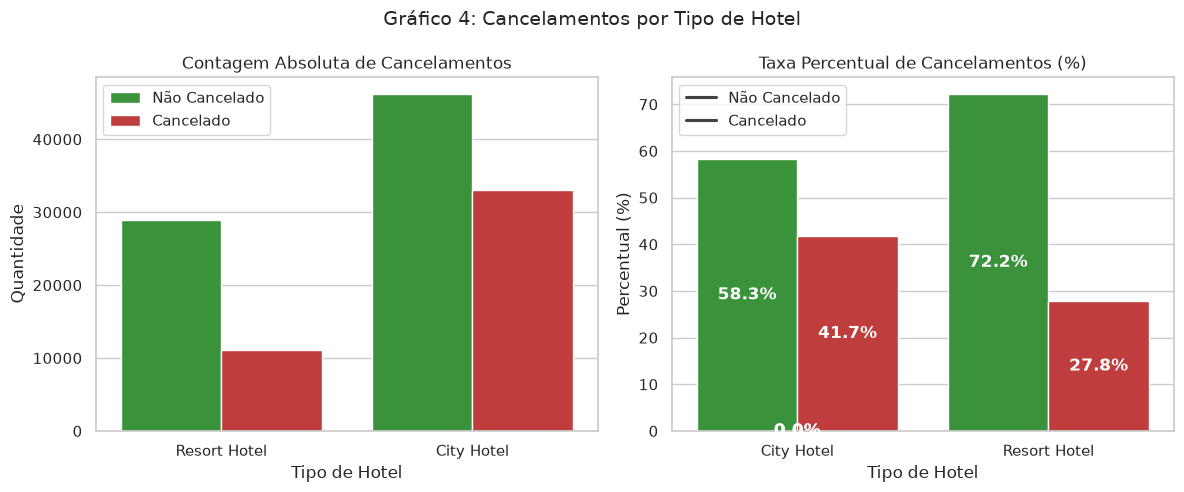

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Absoluto
sns.countplot(data=df, x='hotel', hue='is_canceled', palette=['#2ca02c', '#d62728'], ax=axes[0])
axes[0].set_title('Contagem Absoluta de Cancelamentos')
axes[0].set_xlabel('Tipo de Hotel')
axes[0].set_ylabel('Quantidade')
axes[0].legend(['Não Cancelado', 'Cancelado'])

# Percentual
prop = df.groupby('hotel')['is_canceled'].value_counts(normalize=True).mul(100).rename('Percentual').reset_index()
sns.barplot(data=prop, x='hotel', y='Percentual', hue='is_canceled', palette=['#2ca02c', '#d62728'], ax=axes[1])
axes[1].set_title('Taxa Percentual de Cancelamentos (%)')
axes[1].set_xlabel('Tipo de Hotel')
axes[1].set_ylabel('Percentual (%)')
axes[1].legend(['Não Cancelado', 'Cancelado'])

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

plt.suptitle('Gráfico 4: Cancelamentos por Tipo de Hotel', fontsize=14)
plt.tight_layout()
plt.show()

#### Respostas ao Gráfico 4:
16. **Qual hotel possui maior número absoluto de cancelamentos?**  
    O **City Hotel** (33.102 cancelamentos vs. 11.122 do Resort).
17. **Qual apresenta maior proporção de cancelamentos?**  
    O **City Hotel** (**41,7%** contra **27,8%** do Resort).
18. **Por que apenas o número absoluto pode levar a uma interpretação equivocada?**  
    Porque o City Hotel tem muito mais reservas no total. O percentual confirma que sua taxa de evasão relativa é realmente maior.
19. **O comportamento de cancelamento parece diferir entre os hotéis?**  
    Sim, o cancelamento é significativamente mais frequente no City Hotel.

### Gráfico 5 – Cancelamento e antecedência da reserva (`lead_time`)

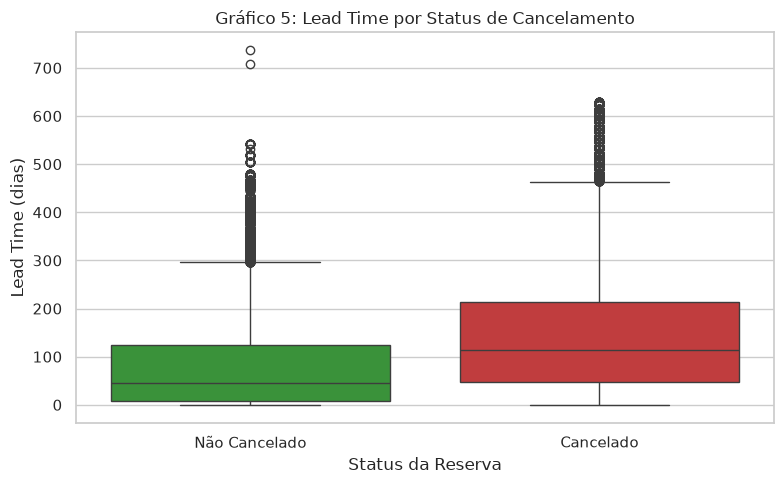

,mean,std,50%,75%
is_canceled,,,,
0,79.98,91.11,45.00,124.00
1,144.85,118.62,113.00,214.00


In [12]:
plt.figure(figsize=(8, 5))
df_plot = df.copy()
df_plot['Status'] = df_plot['is_canceled'].map({0: 'Não Cancelado', 1: 'Cancelado'})

sns.boxplot(data=df_plot, x='Status', y='lead_time', hue='Status', palette={'Não Cancelado': '#2ca02c', 'Cancelado': '#d62728'}, legend=False)
plt.title('Gráfico 5: Lead Time por Status de Cancelamento')
plt.xlabel('Status da Reserva')
plt.ylabel('Lead Time (dias)')
plt.tight_layout()
plt.show()

df.groupby('is_canceled')['lead_time'].describe()[['mean', 'std', '50%', '75%']]

#### Respostas ao Gráfico 5:
20. **Qual grupo apresenta maior mediana de antecedência?**  
    O grupo de **cancelados** (mediana de **113 dias** vs. **49 dias** dos não cancelados).
21. **Qual apresenta maior dispersão?**  
    O grupo de **cancelados** (desvio padrão de 123,9 dias vs. 98,2 dias).
22. **As reservas canceladas parecem ter sido feitas com maior antecedência?**  
    Sim, a distribuição das canceladas é claramente superior em prazos.
23. **O gráfico fornece evidência de uma possível relação entre antecedência e cancelamento?**  
    Sim, mostra forte relação positiva: quanto maior a antecedência, maior a probabilidade de cancelamento.
24. **Que hipótese sobre cancelamentos poderia ser investigada depois?**  
    Reservas feitas com muita antecedência têm maior incerteza por parte do cliente, levando ao cancelamento posterior.

### Gráfico 6 – Demanda ao longo do ano por tipo de hotel

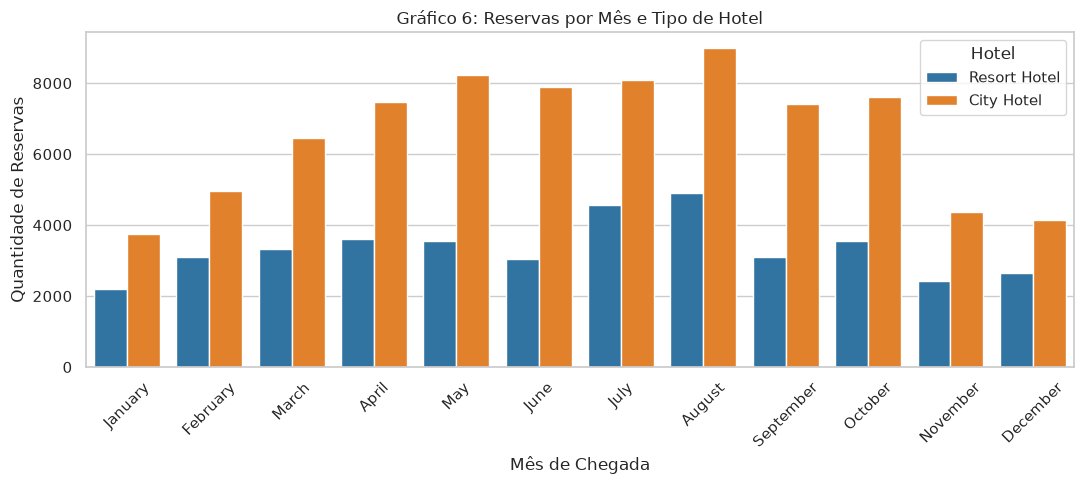

In [135]:
meses = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(11, 5))
sns.countplot(data=df, x='arrival_date_month', order=meses, hue='hotel', palette={'Resort Hotel': '#1f77b4', 'City Hotel': '#ff7f0e'})
plt.title('Gráfico 6: Reservas por Mês e Tipo de Hotel')
plt.xlabel('Mês de Chegada')
plt.ylabel('Quantidade de Reservas')
plt.xticks(rotation=45)
plt.legend(title='Hotel')
plt.tight_layout()
plt.show()

#### Respostas ao Gráfico 6:
25. **Quais meses apresentam maior volume de reservas?**  
    **Julho e Agosto** (verão europeu), seguidos por **Maio e Outubro**.
26. **Existem períodos de baixa demanda?**  
    Sim, os meses de inverno: **Novembro, Dezembro e Janeiro**.
27. **O padrão é semelhante nos dois hotéis?**  
    Sim no pico de verão, mas o City Hotel mantém demanda alta também na primavera e outono.
28. **Em quais períodos as diferenças são mais evidentes?**  
    Na **primavera e outono** (Maio, Junho, Setembro, Outubro), onde o City Hotel supera amplamente o Resort.
29. **Que implicação isso poderia ter para planejamento de capacidade ou preços?**  
    Subir preços e exigir depósitos no verão; criar promoções e pacotes no inverno.

### Gráfico 7 – Relação entre antecedência (`lead_time`) e preço (`adr`)

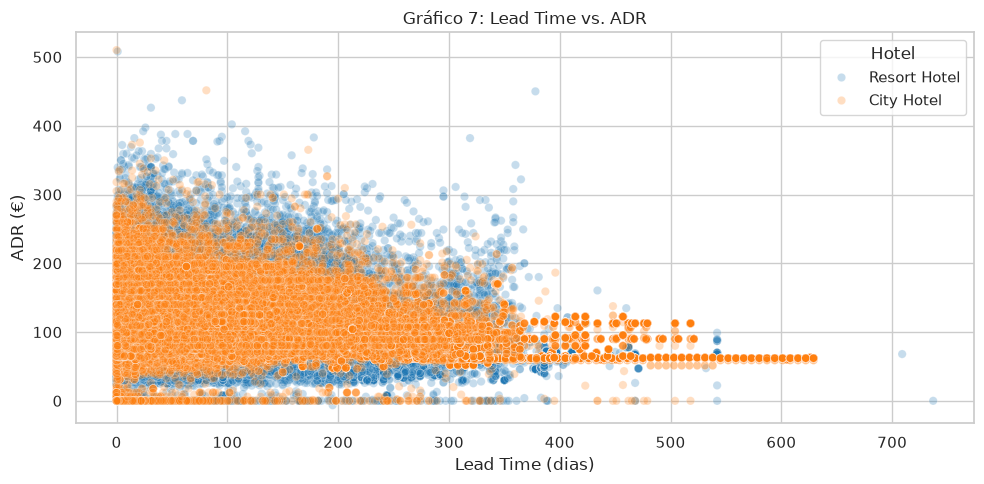

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df[df['adr'] < 600], x='lead_time', y='adr', hue='hotel', alpha=0.25, palette={'Resort Hotel': '#1f77b4', 'City Hotel': '#ff7f0e'})
plt.title('Gráfico 7: Lead Time vs. ADR')
plt.xlabel('Lead Time (dias)')
plt.ylabel('ADR (€)')
plt.legend(title='Hotel')
plt.tight_layout()
plt.show()

#### Respostas ao Gráfico 7:
30. **É possível observar uma tendência entre antecedência e preço?**  
    Não há tendência clara visível.
31. **A relação parece positiva, negativa ou inexistente?**  
    Praticamente **inexistente** (correlação quase nula, $r = -0,06$).
32. **O padrão é diferente entre os hotéis?**  
    Não significativamente; ambos mantêm faixas de preços estáveis ao longo do tempo.
33. **Há regiões de grande concentração?**  
    Sim, em **lead time de 0 a 100 dias** com **ADR entre 50 € e 150 €**.
34. **Existem pontos que fogem do padrão geral?**  
    Sim, o valor isolado de 5.400 € e reservas com mais de 500 dias.

### Gráfico 8 – Relação entre duração da estadia e preço

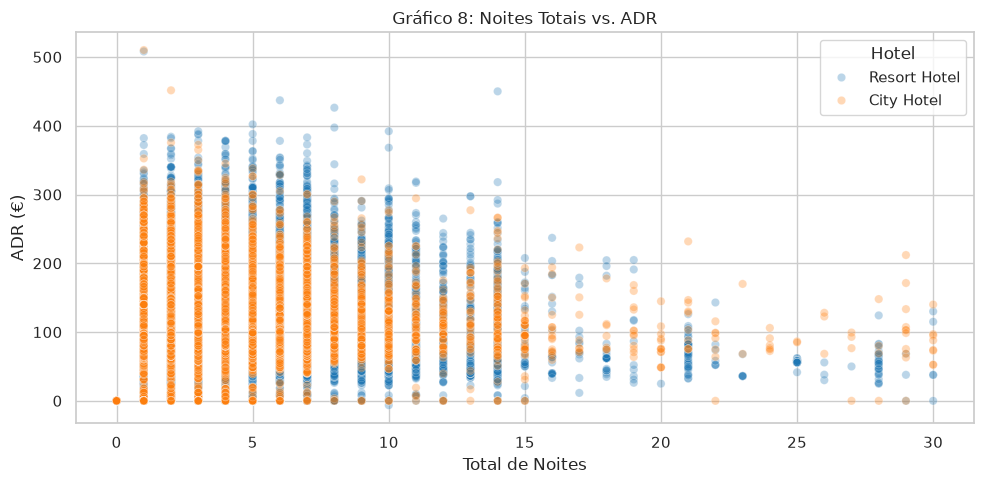

In [15]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df[(df['adr'] < 600) & (df['total_nights'] <= 30)], x='total_nights', y='adr', hue='hotel', alpha=0.3, palette={'Resort Hotel': '#1f77b4', 'City Hotel': '#ff7f0e'})
plt.title('Gráfico 8: Noites Totais vs. ADR')
plt.xlabel('Total de Noites')
plt.ylabel('ADR (€)')
plt.legend(title='Hotel')
plt.tight_layout()
plt.show()

#### Respostas ao Gráfico 8:
35. **Como o preço varia com o aumento da duração?**  
    O preço diário permanece estável para estadias comuns e reduz levemente em estadias muito longas.
36. **Existe uma tendência clara?**  
    Não há tendência linear forte, mas diárias muito caras ocorrem apenas em estadias curtas (1 a 4 noites).
37. **Há grande concentração em determinadas durações?**  
    Sim, em **1, 2, 3, 4 e 7 noites**.
38. **Existem reservas com duração muito diferente da maioria?**  
    Sim, algumas estadias de 14 a mais de 30 noites.
39. **O comportamento parece diferente entre os hotéis?**  
    Sim. O City Hotel foca em estadias curtas (1-3 noites), enquanto o Resort possui mais estadias de 7 e 14 noites.

### Gráfico 9 – Solicitações especiais por perfil de cliente (`customer_type`)

/tmp/ipykernel_251621/2203809823.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_req, x='customer_type', y='total_of_special_requests', palette='Blues_d')


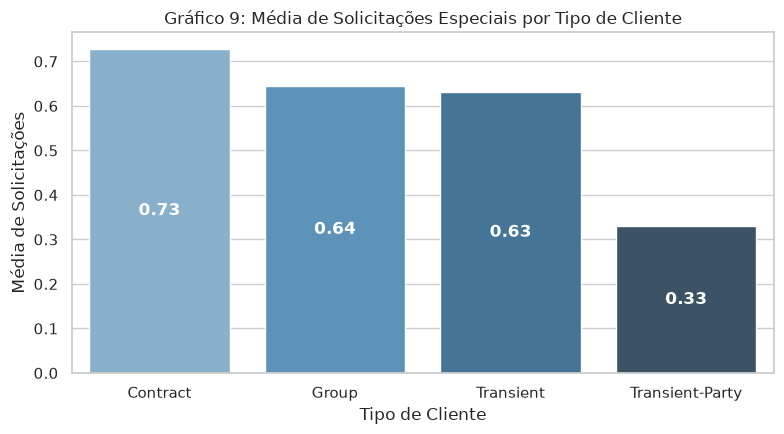

In [154]:
mean_req = df.groupby('customer_type')['total_of_special_requests'].mean().reset_index()

plt.figure(figsize=(8, 4.5))
sns.barplot(data=mean_req, x='customer_type', y='total_of_special_requests', palette='Blues_d')
plt.title('Gráfico 9: Média de Solicitações Especiais por Tipo de Cliente')
plt.xlabel('Tipo de Cliente')
plt.ylabel('Média de Solicitações')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                       ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

#### Respostas ao Gráfico 9:
40. **Qual tipo de cliente apresenta maior média?**  
    **Transient-Party** (0,69) e **Transient** (0,60).
41. **Qual apresenta menor média?**  
    **Group** (0,38) e **Contract** (0,46).
42. **As diferenças entre os grupos parecem relevantes?**  
    Sim, clientes individuais fazem quase o dobro de pedidos especiais quando comparados a grupos.
43. **Que interpretação de negócio poderia ser levantada a partir desse padrão?**  
    Clientes individuais viajam a lazer e exigem mais personalização, enquanto grupos seguem contratações padronizadas.

---
## 5. Investigação de Outliers

In [17]:
def outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = len(df[(df[col] < lim_inf) | (df[col] > lim_sup)])
    print(f"{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f} | Limites: [{lim_inf:.2f}, {lim_sup:.2f}] | Outliers: {n_out} ({n_out/len(df)*100:.2f}%)")

outliers_iqr('adr')
outliers_iqr('lead_time')

adr: Q1=69.29, Q3=126.00, IQR=56.71 | Limites: [-15.77, 211.06] | Outliers: 3793 (3.18%)
lead_time: Q1=18.00, Q3=160.00, IQR=142.00 | Limites: [-195.00, 373.00] | Outliers: 3005 (2.52%)


### Respostas da Seção 5:
9. **Quantos registros são classificados como possíveis outliers?**  
   - `adr`: **3.793 registros (3,18%)** acima de 211,05 €.  
   - `lead_time`: **3.005 registros (2,52%)** acima de 376 dias.

10. **Os valores identificados aparecem também nos boxplots?**  
    Sim, são exatamente os pontos desenhados fora dos bigodes dos boxplots.

11. **Você removeria esses registros? Justifique considerando o contexto das reservas.**  
    Apenas erros claros de digitação (como o ADR = 5.400 € e valores negativos). Os demais representam reservas legítimas de alta temporada e grandes eventos que não devem ser descartadas.

---
## 6. Correlação entre Atributos Numéricos

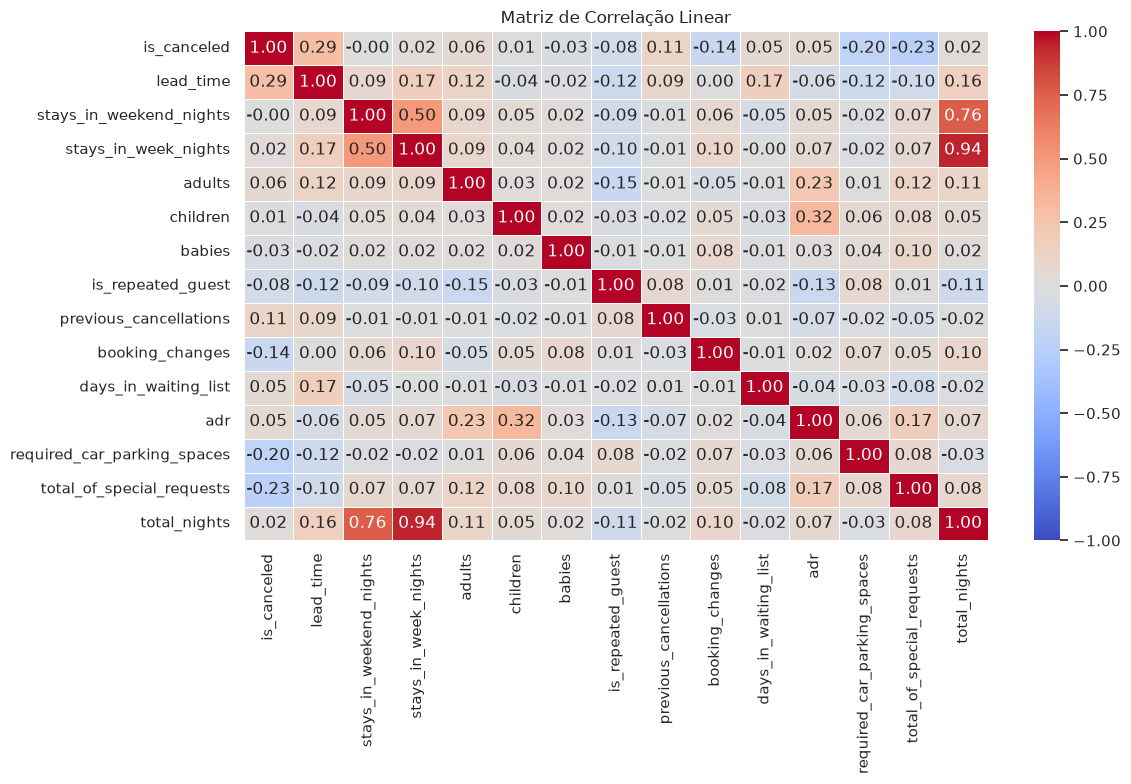

In [167]:
cols_corr = [
    'is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
    'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'total_nights'
]

corr = df[cols_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação Linear')
plt.tight_layout()
plt.show()

### Respostas da Seção 6:
12. **Quais pares apresentam as maiores correlações em módulo?**  
    - `total_nights` com `stays_in_week_nights` ($r = 0,94$).  
    - `is_canceled` e `lead_time` ($r = 0,29$).  
    - `adr` e `adults` ($r = 0,26$).  
    - `is_canceled` e `required_car_parking_spaces` ($r = -0,20$).

13. **As correlações mais fortes são coerentes com os scatter plots?**  
    Sim, confirmam a ausência de correlação entre `lead_time` e `adr` ($r = -0,06$) e o forte impacto da antecedência nos cancelamentos.

14. **Existe alguma correlação que possa ser enganosa por causa da natureza do atributo ou do contexto?**  
    Sim, variáveis discretas com muitos zeros (como `days_in_waiting_list`) têm coeficientes lineares atenuados que escondem relações não-lineares.

15. **Escolha uma relação que mereceria investigação em uma etapa posterior e explique por quê.**  
    A relação entre **vagas de estacionamento e cancelamento**: clientes que solicitam estacionamento raramente cancelam ($r = -0,20$), sendo um ótimo preditor de presença confirmada.

---
## 7. Síntese: O que os dados revelam?

### Principais Achados:
1. **Antecedência e Cancelamento:** Reservas canceladas foram feitas com o dobro de antecedência (mediana de 113 vs. 49 dias).
2. **Diferenças entre Hotéis:** O City Hotel tem maior preço mediano (105 € vs 75 €) e maior taxa de cancelamento (41,7% vs 27,8%).
3. **Sazonalidade:** Pico de demanda no verão europeu (Julho e Agosto) e forte queda no inverno (Novembro a Janeiro).
4. **Pedidos Especiais:** Clientes individuais (*Transient*) demandam quase o dobro de solicitações em relação a grupos.
5. **Qualidade dos Dados:** Presença de 94% de nulos em `company`, outlier de 5.400 € em ADR e reservas com 0 pessoas.
6. **Vaga de Garagem:** Solicitação de estacionamento é um forte indicativo de que a reserva não será cancelada.

---

### 3 Ideias para Projetos Futuros de Mineração de Dados:
1. **Predição de Cancelamento (*Churn Prediction*):** Modelo supervisionado (*Random Forest* ou *XGBoost*) para estimar a chance de cancelamento no momento da reserva.
2. **Segmentação de Clientes (*Clustering*):** Agrupamento não supervisionado (*K-Means*) por tipo de viagem, gastos e perfil familiar.
3. **Previsão de Demanda e Preço Dinâmico (*Forecasting*):** Modelo de séries temporais para prever ocupação e sugerir tarifas ideais por temporada.